In [2]:
import pandas as pd
import numpy as np

from sklearn.decomposition import PCA

import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
sp500_px = pd.read_csv('data/sp500_data.csv.gz')
sp500_px.set_index("Unnamed: 0", inplace=True)
sp500_px

,ADS,CA,MSFT,RHT,CTSH,CSC,EMC,IBM,XRX,ALTR,...,WAT,ALXN,AMGN,BXLT,BIIB,CELG,GILD,REGN,VRTX,HSIC
Unnamed: 0,,,,,,,,,,,,,,,,,,,,,
1993-01-29,0.000000,0.060124,-0.022100,0.000000,0.000000,0.018897,0.007368,0.092165,0.259140,-0.007105,...,0.000000,0.000000,0.347160,0.000000,0.041670,0.000000,0.015564,1.750000,0.125000,0.000000
1993-02-01,0.000000,-0.180389,0.027621,0.000000,0.000000,0.018889,0.018425,0.115207,-0.100775,0.063893,...,0.000000,0.000000,-0.231440,0.000000,0.000000,-0.010410,0.007782,1.250000,0.125000,0.000000
1993-02-02,0.000000,-0.120257,0.035900,0.000000,0.000000,-0.075573,0.029482,-0.023041,0.028796,-0.014192,...,0.000000,0.000000,-0.115720,0.000000,0.000000,0.000000,-0.007792,-0.250000,0.000000,0.000000
1993-02-03,0.000000,0.060124,-0.024857,0.000000,0.000000,-0.151128,0.003689,-0.253454,-0.043190,-0.007105,...,0.000000,0.000000,-0.086790,0.000000,0.041670,-0.041670,-0.038919,-0.500000,0.062500,0.000000
1993-02-04,0.000000,-0.360770,-0.060757,0.000000,0.000000,0.113350,-0.022114,0.069862,0.000000,-0.007096,...,0.000000,0.000000,0.144650,0.000000,-0.041660,-0.031260,-0.046711,0.000000,0.062500,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2015-06-25,0.019989,-0.529999,-0.379997,0.080002,0.350003,-0.580002,-0.457999,-1.720001,-0.009936,0.039997,...,-2.500000,1.889999,-2.060012,0.150002,-1.630004,-0.990005,-2.250000,1.270019,-1.919998,-0.080002
2015-06-26,-1.299988,-0.330000,-0.390004,-1.820000,0.190003,0.330002,-0.328565,-0.769989,0.020000,0.000000,...,-0.070007,-2.380005,-1.390000,0.550004,-3.509979,-1.080002,-0.800003,-1.900024,-3.629997,0.440002
2015-06-29,-10.299988,-0.410000,-0.670002,-1.250000,-1.919998,-0.510002,-0.139999,-0.949997,-0.100000,-0.040001,...,-2.250000,-5.490005,-5.029999,0.090000,-8.290009,-1.209999,-2.419998,-9.620026,-3.770004,-2.479996


In [4]:
oil_px = sp500_px[['XOM', 'CVX']]
oil_px

,XOM,CVX
Unnamed: 0,,
1993-01-29,-0.016991,0.072921
1993-02-01,0.016991,0.102089
1993-02-02,0.084954,0.029168
1993-02-03,0.067964,0.058337
1993-02-04,0.034378,0.044272
...,...,...
2015-06-25,-0.919998,-1.110001
2015-06-26,0.029999,0.360000
2015-06-29,-0.230003,-0.809998


In [5]:
pcs = PCA(n_components=2)
pcs.fit(oil_px)
loadings = pd.DataFrame(pcs.components_, columns=oil_px.columns)
loadings

,XOM,CVX
0,0.664711,0.747101
1,0.747101,-0.664711


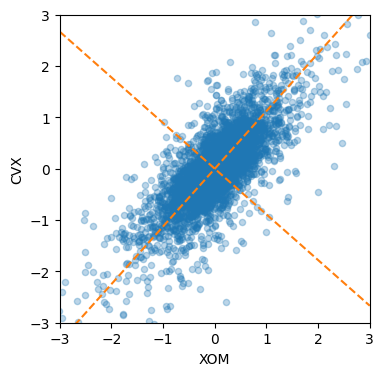

In [6]:
def abline(slope, intercept, ax):
 """Calculate coordinates of a line based on slope and intercept"""
 x_vals = np.array(ax.get_xlim())
 return (x_vals, intercept + slope * x_vals)
ax = oil_px.plot.scatter(x='XOM', y='CVX', alpha=0.3, figsize=(4, 4))
ax.set_xlim(-3, 3)
ax.set_ylim(-3, 3)
ax.plot(*abline(loadings.loc[0, 'CVX'] / loadings.loc[0, 'XOM'], 0, ax),
 '--', color='C1')
ax.plot(*abline(loadings.loc[1, 'CVX'] / loadings.loc[1, 'XOM'], 0, ax),
 '--', color='C1')

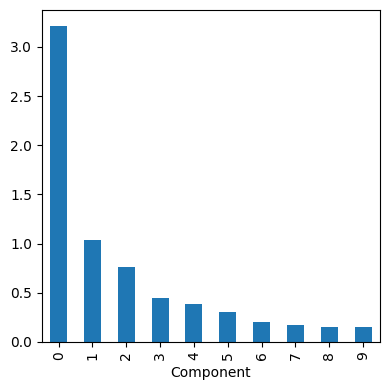

In [7]:
syms = sorted(['AAPL', 'MSFT', 'CSCO', 'INTC', 'CVX', 'XOM', 'SLB', 'COP',
        'JPM', 'WFC', 'USB', 'AXP', 'WMT', 'TGT', 'HD', 'COST'])



top_sp = sp500_px.loc[pd.to_datetime(sp500_px.index) >= '2011-01-01', syms]

sp_pca = PCA()
sp_pca.fit(top_sp)

explained_variance = pd.DataFrame(sp_pca.explained_variance_)
ax = explained_variance.head(10).plot.bar(legend=False, figsize=(4, 4))
ax.set_xlabel('Component')

plt.tight_layout()
plt.show()

In [8]:
sp500_px.columns

Index(['ADS', 'CA', 'MSFT', 'RHT', 'CTSH', 'CSC', 'EMC', 'IBM', 'XRX', 'ALTR',
       ...
       'WAT', 'ALXN', 'AMGN', 'BXLT', 'BIIB', 'CELG', 'GILD', 'REGN', 'VRTX',
       'HSIC'],
      dtype='object', length=517)

In [9]:
sp500_px.index

Index(['1993-01-29', '1993-02-01', '1993-02-02', '1993-02-03', '1993-02-04',
       '1993-02-05', '1993-02-08', '1993-02-09', '1993-02-10', '1993-02-11',
       ...
       '2015-06-18', '2015-06-19', '2015-06-22', '2015-06-23', '2015-06-24',
       '2015-06-25', '2015-06-26', '2015-06-29', '2015-06-30', '2015-07-01'],
      dtype='object', name='Unnamed: 0', length=5647)

In [10]:
top_sp

,AAPL,AXP,COP,COST,CSCO,CVX,HD,INTC,JPM,MSFT,SLB,TGT,USB,WFC,WMT,XOM
Unnamed: 0,,,,,,,,,,,,,,,,
2011-01-03,0.527368,0.093870,-0.336272,-0.240605,0.035704,0.240681,0.099184,-0.137211,0.512093,-0.061805,-0.325923,0.455646,-0.234866,0.250042,0.294839,0.736805
2011-01-04,-0.154321,-0.431788,-0.463161,-0.171859,0.008926,-0.584516,-0.541005,0.025726,0.335894,0.132440,-2.030049,-0.580720,-0.153566,0.000000,0.142951,0.168668
2011-01-05,0.597152,0.895406,-0.057104,-0.859307,0.169599,0.446985,-0.054099,-0.214392,0.689468,0.088294,1.536499,-0.482448,0.198732,0.857284,-0.303772,0.026631
2011-01-06,-0.132850,-0.612646,-0.463161,0.249200,0.035706,-0.919751,-0.189354,0.085757,0.070713,0.688689,-1.927614,-0.786210,-0.532962,0.000000,-0.312709,0.248558
2011-01-07,0.285820,-0.537242,-0.006350,-0.257788,0.098187,0.180511,-0.036064,-0.042878,-0.795539,-0.035317,0.931215,-0.089345,-0.171633,-0.651894,0.169758,0.337329
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2015-06-25,-1.360001,-1.105863,-0.949997,-1.000000,-0.158775,-1.110001,-1.000000,-0.030000,-0.665647,-0.379997,-0.690003,0.080002,-0.238625,-0.580002,-0.589996,-0.919998
2015-06-26,-0.919998,-0.288920,0.029998,0.119996,-0.208393,0.360000,-0.169999,-0.490000,0.009930,-0.390004,0.279999,-0.409996,-0.020001,0.099999,0.160004,0.029999
2015-06-29,-0.930000,-1.414705,-0.410000,-1.319993,-0.446558,-0.809998,-1.019997,-0.310002,-0.476886,-0.670002,0.060006,-1.390007,-0.500000,-0.739998,-0.380005,-0.230003


In [11]:
loadings = pd.DataFrame(sp_pca.components_[0:5, :], 
                        columns=top_sp.columns)
loadings

,AAPL,AXP,COP,COST,CSCO,CVX,HD,INTC,JPM,MSFT,SLB,TGT,USB,WFC,WMT,XOM
0,0.300825,0.246332,0.261529,0.273634,0.064059,0.444490,0.207983,0.076956,0.196397,0.105012,0.481786,0.148833,0.116421,0.145684,0.122304,0.317952
1,0.505116,0.139426,-0.174212,0.416307,0.031939,-0.289373,0.278002,0.033898,0.040723,0.053954,-0.472494,0.228123,0.054796,0.047427,0.222889,-0.154192
2,0.786730,-0.135458,0.002367,-0.465862,0.007524,-0.082374,-0.166320,0.003518,-0.062261,-0.016248,0.194822,-0.160833,-0.048976,-0.041932,-0.175806,-0.090167
3,-0.120586,0.061814,-0.206026,0.092596,0.003904,-0.577665,0.162814,-0.001605,0.057687,-0.012558,0.680914,0.109895,0.016752,0.018614,0.058439,-0.295204
4,-0.111576,0.596666,0.005813,-0.555529,0.039860,-0.109016,0.185488,0.072047,0.385160,0.077135,-0.181332,0.055557,0.155440,0.216425,-0.091541,-0.013277


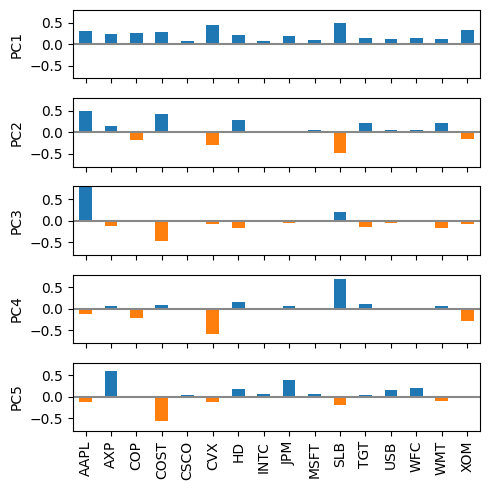

In [12]:
maxPC = 1.01 * loadings.loc[0:5, :].abs().to_numpy().max()

f, axes = plt.subplots(5, 1, figsize=(5, 5), sharex=True)

for i, ax in enumerate(axes):
    pc_loadings = loadings.loc[i, :]
    colors = ['C0' if l > 0 else 'C1' for l in pc_loadings]
    ax.axhline(color='#888888')
    pc_loadings.plot.bar(ax=ax, color=colors)
    ax.set_ylabel(f'PC{i+1}')
    ax.set_ylim(-maxPC, maxPC)

plt.tight_layout()
plt.show()

In [13]:
import prince
from adjustText import adjust_text

housetasks = pd.read_csv("data/housetasks.csv", index_col=0)
housetasks


,Wife,Alternating,Husband,Jointly
Task,,,,
Laundry,156,14,2,4
Main_meal,124,20,5,4
Dinner,77,11,7,13
Breakfast,82,36,15,7
Tidying,53,11,1,57
Dishes,32,24,4,53
Shopping,33,23,9,55
Official,12,46,23,15
Driving,10,51,75,3


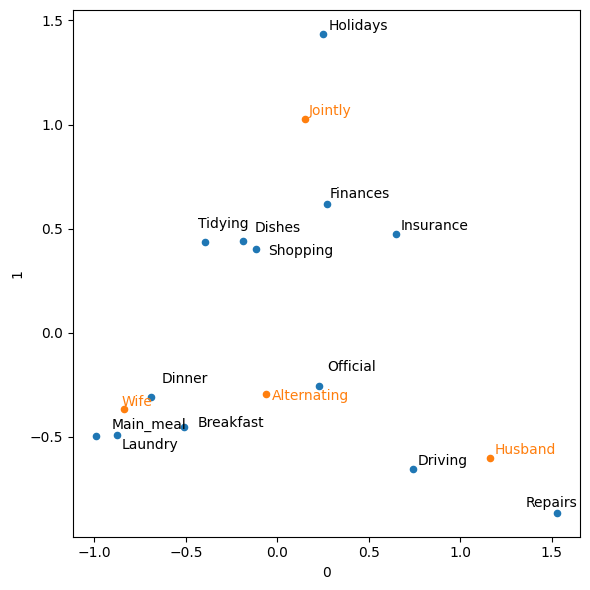

In [14]:
ca = prince.CA(n_components=2)
ca = ca.fit(housetasks)

ax = ca.row_coordinates(housetasks).plot.scatter(x=0, y=1, figsize=(6,6))
ca.column_coordinates(housetasks).plot.scatter(x=0, y=1, ax=ax, c='C1')
texts = []
for idx, row in ca.row_coordinates(housetasks).iterrows():
    texts.append(plt.text(row[0], row[1], idx))
for idx, row in ca.column_coordinates(housetasks).iterrows():
    texts.append(plt.text(row[0], row[1], idx, color='C1'))
adjust_text(texts, only_move={'points':'y', 'texts':'y'}) 
plt.tight_layout()
plt.show()

In [15]:
from sklearn.cluster import KMeans
df = sp500_px.loc[sp500_px.index >= '2011-01-01', ['XOM', 'CVX']]
kmeans = KMeans(n_clusters=4, n_init='auto').fit(df)
df['cluster'] = kmeans.labels_
df

,XOM,CVX,cluster
Unnamed: 0,,,
2011-01-03,0.736805,0.240681,2
2011-01-04,0.168668,-0.584516,3
2011-01-05,0.026631,0.446985,2
2011-01-06,0.248558,-0.919751,3
2011-01-07,0.337329,0.180511,2
...,...,...,...
2015-06-25,-0.919998,-1.110001,1
2015-06-26,0.029999,0.360000,2
2015-06-29,-0.230003,-0.809998,3


In [16]:
centers = pd.DataFrame(kmeans.cluster_centers_, columns=['XOM', 'CVX'])
centers

,XOM,CVX
0,0.960948,1.376572
1,-1.137958,-1.746642
2,0.242519,0.336479
3,-0.328125,-0.564848


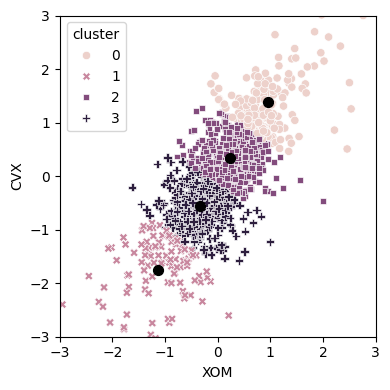

In [17]:
fig, ax = plt.subplots(figsize=(4, 4))
ax = sns.scatterplot(x='XOM', y='CVX', hue='cluster', style='cluster', 
                     ax=ax, data=df)
ax.set_xlim(-3, 3)
ax.set_ylim(-3, 3)
centers.plot.scatter(x='XOM', y='CVX', ax=ax, s=50, color='black')

plt.tight_layout()
plt.show()

In [18]:
syms = sorted(['AAPL', 'MSFT', 'CSCO', 'INTC', 'CVX', 'XOM', 'SLB', 'COP', 
               'JPM', 'WFC', 'USB', 'AXP', 'WMT', 'TGT', 'HD', 'COST'])
top_sp = sp500_px.loc[sp500_px.index >= '2011-01-01', syms]
kmeans = KMeans(n_clusters=5, n_init='auto').fit(top_sp)

top_sp["cluster"] = kmeans.labels_

centers = pd.DataFrame(kmeans.cluster_centers_, columns=syms)

top_sp

,AAPL,AXP,COP,COST,CSCO,CVX,HD,INTC,JPM,MSFT,SLB,TGT,USB,WFC,WMT,XOM,cluster
Unnamed: 0,,,,,,,,,,,,,,,,,
2011-01-03,0.527368,0.093870,-0.336272,-0.240605,0.035704,0.240681,0.099184,-0.137211,0.512093,-0.061805,-0.325923,0.455646,-0.234866,0.250042,0.294839,0.736805,4
2011-01-04,-0.154321,-0.431788,-0.463161,-0.171859,0.008926,-0.584516,-0.541005,0.025726,0.335894,0.132440,-2.030049,-0.580720,-0.153566,0.000000,0.142951,0.168668,0
2011-01-05,0.597152,0.895406,-0.057104,-0.859307,0.169599,0.446985,-0.054099,-0.214392,0.689468,0.088294,1.536499,-0.482448,0.198732,0.857284,-0.303772,0.026631,3
2011-01-06,-0.132850,-0.612646,-0.463161,0.249200,0.035706,-0.919751,-0.189354,0.085757,0.070713,0.688689,-1.927614,-0.786210,-0.532962,0.000000,-0.312709,0.248558,0
2011-01-07,0.285820,-0.537242,-0.006350,-0.257788,0.098187,0.180511,-0.036064,-0.042878,-0.795539,-0.035317,0.931215,-0.089345,-0.171633,-0.651894,0.169758,0.337329,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2015-06-25,-1.360001,-1.105863,-0.949997,-1.000000,-0.158775,-1.110001,-1.000000,-0.030000,-0.665647,-0.379997,-0.690003,0.080002,-0.238625,-0.580002,-0.589996,-0.919998,2
2015-06-26,-0.919998,-0.288920,0.029998,0.119996,-0.208393,0.360000,-0.169999,-0.490000,0.009930,-0.390004,0.279999,-0.409996,-0.020001,0.099999,0.160004,0.029999,3
2015-06-29,-0.930000,-1.414705,-0.410000,-1.319993,-0.446558,-0.809998,-1.019997,-0.310002,-0.476886,-0.670002,0.060006,-1.390007,-0.500000,-0.739998,-0.380005,-0.230003,2


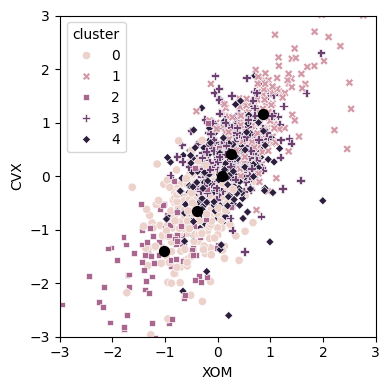

In [19]:
fig, ax = plt.subplots(figsize=(4, 4))
ax = sns.scatterplot(x='XOM', y='CVX', hue='cluster', style='cluster', 
                     ax=ax, data=top_sp)
ax.set_xlim(-3, 3)
ax.set_ylim(-3, 3)
centers.plot.scatter(x='XOM', y='CVX', ax=ax, s=50, color='black')

plt.tight_layout()
plt.show()

In [20]:
from collections import Counter
print(Counter(kmeans.labels_))

Counter({np.int32(3): 288, np.int32(4): 285, np.int32(0): 273, np.int32(1): 178, np.int32(2): 107})


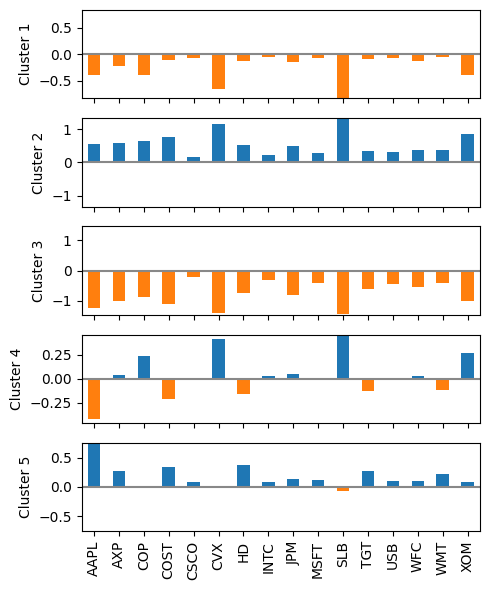

In [21]:
centers = pd.DataFrame(kmeans.cluster_centers_, columns=syms)

f, axes = plt.subplots(5, 1, figsize=(5, 6), sharex=True)
for i, ax in enumerate(axes):
    center = centers.loc[i, :]
    maxPC = 1.01 * np.max(np.max(np.abs(center)))
    colors = ['C0' if l > 0 else 'C1' for l in center]
    ax.axhline(color='#888888')
    center.plot.bar(ax=ax, color=colors)
    ax.set_ylabel(f'Cluster {i + 1}')
    ax.set_ylim(-maxPC, maxPC)

plt.tight_layout()
plt.show()

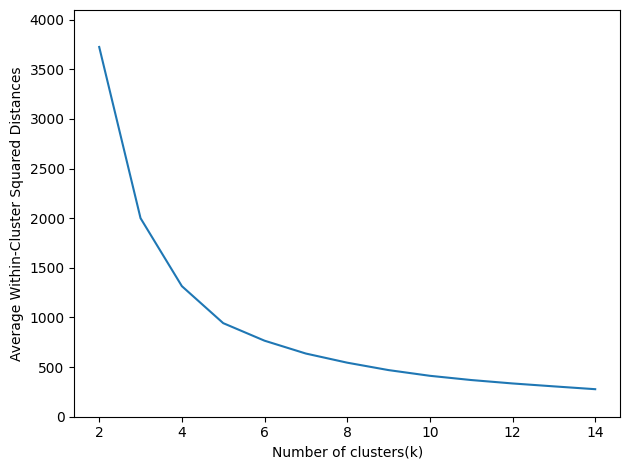

In [22]:
inertia = []
for n_clusters in range(2, 15):
    kmeans = KMeans(n_clusters=n_clusters, random_state=0, n_init='auto').fit(top_sp)
    inertia.append(kmeans.inertia_ / n_clusters)
inertias = pd.DataFrame({'n_clusters': range(2, 15), 'inertia': inertia})
ax = inertias.plot(x='n_clusters', y='inertia')
plt.xlabel('Number of clusters(k)')
plt.ylabel('Average Within-Cluster Squared Distances')
plt.ylim((0, 1.1 * inertias.inertia.max()))
ax.legend().set_visible(False)

plt.tight_layout()
plt.show()

In [23]:
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

syms1 = ['AAPL', 'AMZN', 'AXP', 'COP', 'COST', 'CSCO', 'CVX', 'GOOGL', 'HD', 
         'INTC', 'JPM', 'MSFT', 'SLB', 'TGT', 'USB', 'WFC', 'WMT', 'XOM']
df = sp500_px.loc[sp500_px.index >= '2011-01-01', syms1].transpose()


Z = linkage(df, method='complete')
print(Z.shape)

(17, 4)


In [24]:
df

Unnamed: 0,2011-01-03,2011-01-04,2011-01-05,2011-01-06,2011-01-07,2011-01-10,2011-01-11,2011-01-12,2011-01-13,2011-01-14,...,2015-06-18,2015-06-19,2015-06-22,2015-06-23,2015-06-24,2015-06-25,2015-06-26,2015-06-29,2015-06-30,2015-07-01
AAPL,0.527368,-0.154321,0.597152,-0.132850,0.285820,0.485766,-0.434780,0.157012,0.069781,0.347552,...,0.649994,-1.110001,0.120003,-0.450004,0.900002,-1.360001,-0.919998,-0.930000,-0.140000,-0.300004
AMZN,2.850006,-1.139999,3.319992,-0.639999,-2.390000,-0.360000,-1.080002,-1.279999,1.929993,3.250000,...,9.090027,-5.339997,-0.709991,10.399994,-4.130005,2.029999,-3.660004,-5.120026,-0.110016,-1.959991
AXP,0.093870,-0.431788,0.895406,-0.612646,-0.537242,0.245056,0.056553,-0.414713,0.235633,1.244141,...,0.528023,-0.328765,0.567875,-0.079703,-0.199258,-1.105863,-0.288920,-1.414705,-0.449997,-0.239997
COP,-0.336272,-0.463161,-0.057104,-0.463161,-0.006350,0.095172,0.380682,0.038061,-0.704260,0.279170,...,-0.220002,-0.200001,0.100002,0.489998,-0.299999,-0.949997,0.029998,-0.410000,-0.119999,-1.479999
COST,-0.240605,-0.171859,-0.859307,0.249200,-0.257788,0.171865,0.446837,0.249200,0.240604,0.996799,...,1.009995,-0.289993,-0.649994,-0.790008,-1.000000,-1.000000,0.119996,-1.319993,-1.320007,0.700012
CSCO,0.035704,0.008926,0.169599,0.035706,0.098187,-0.133894,-0.017853,0.107116,-0.089263,0.071410,...,0.357246,-0.208393,-0.158775,-0.208393,-0.277860,-0.158775,-0.208393,-0.446558,-0.367171,-0.070000
CVX,0.240681,-0.584516,0.446985,-0.919751,0.180511,-0.464168,0.825197,0.077359,0.146127,0.610301,...,-0.010002,-0.250000,0.459999,0.129997,-0.710006,-1.110001,0.360000,-0.809998,-0.979996,-0.210007
GOOGL,3.938934,-1.751740,4.504517,1.411408,0.265259,-0.295288,-0.850830,-1.241242,-0.140137,3.393402,...,8.179993,1.000000,0.270020,3.600037,-3.909973,-2.349976,-6.650024,-5.500000,-5.050049,-0.359985
HD,0.099184,-0.541005,-0.054099,-0.189354,-0.036064,0.207384,0.225418,0.027053,0.414769,0.703303,...,0.790000,0.790001,0.140000,-0.059998,-0.590004,-1.000000,-0.169999,-1.019997,-0.020005,-0.379997
INTC,-0.137211,0.025726,-0.214392,0.085757,-0.042878,-0.017150,0.188664,0.025726,0.025728,-0.231544,...,0.299999,-0.330002,0.000000,-0.220001,-0.240002,-0.030000,-0.490000,-0.310002,-0.209999,-0.310000


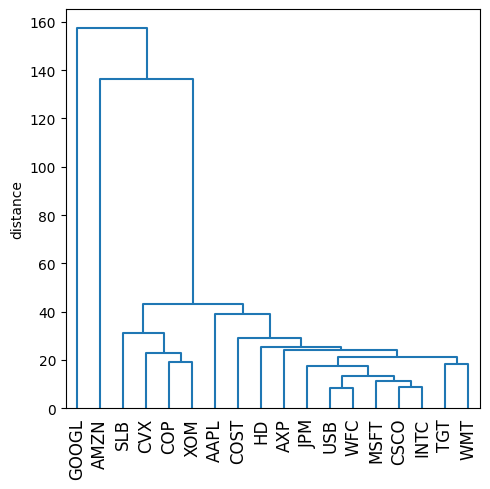

In [25]:
fig, ax = plt.subplots(figsize=(5, 5))
dendrogram(Z, labels=list(df.index), color_threshold=0)
plt.xticks(rotation=90)
ax.set_ylabel('distance')

plt.tight_layout()
plt.show()

In [26]:

memb = fcluster(Z, 4, criterion='maxclust')
memb = pd.Series(memb, index=df.index)
for key, item in memb.groupby(memb):
    print(f"{key} : {', '.join(item.index)}")

1 : COP, CVX, SLB, XOM
2 : AAPL, AXP, COST, CSCO, HD, INTC, JPM, MSFT, TGT, USB, WFC, WMT
3 : AMZN
4 : GOOGL


In [27]:
memb

AAPL     2
AMZN     3
AXP      2
COP      1
COST     2
CSCO     2
CVX      1
GOOGL    4
HD       2
INTC     2
JPM      2
MSFT     2
SLB      1
TGT      2
USB      2
WFC      2
WMT      2
XOM      1
dtype: int32

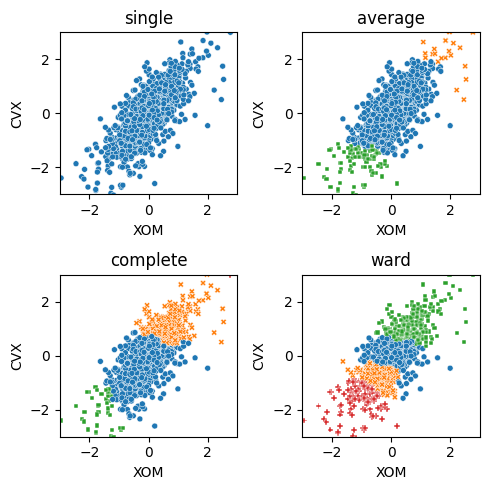

In [28]:
df = sp500_px.loc[sp500_px.index >= '2011-01-01', ['XOM', 'CVX']]
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(5, 5))
for i, method in enumerate(['single', 'average', 'complete', 'ward']):
    ax = axes[i // 2, i % 2]
    Z = linkage(df, method=method)
    colors = [f'C{c+1}' for c in fcluster(Z, 4, criterion='maxclust')]
    ax = sns.scatterplot(x='XOM', y='CVX', hue=colors, style=colors,
                         size=0.5, ax=ax, data=df, legend=False)

    ax.set_xlim(-3, 3)
    ax.set_ylim(-3, 3)
    ax.set_title(method)

plt.tight_layout()
plt.show()

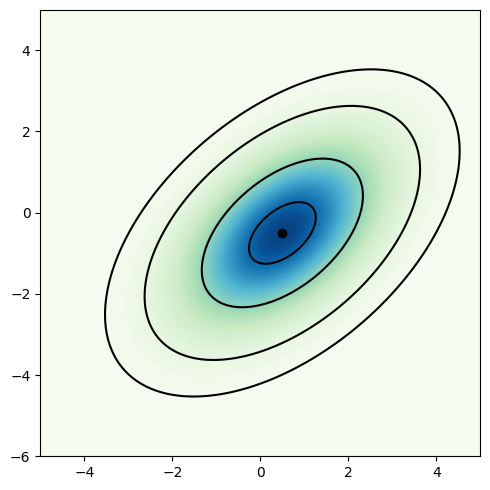

In [29]:
from scipy.stats import multivariate_normal
from matplotlib.cm import GnBu

mean = [0.5, -0.5]
cov = [[2, 1], 
       [1, 2]]
probability = [.5, .75, .95, .99]
def probLevel(p):
    D = 1
    return (1 - p) / (2 * np.pi * D)
levels = [probLevel(p) for p in probability]

fig, ax = plt.subplots(figsize=(5, 5))

x, y = np.mgrid[-5:5:.01, -6:5:.01]
pos = np.empty(x.shape + (2,))
pos[:, :, 0] = x; pos[:, :, 1] = y
rv = multivariate_normal(mean, cov)


CS = ax.contourf(x, y, rv.pdf(pos), cmap=GnBu, levels=50)
ax.contour(CS, levels=levels, colors=['black'])
ax.plot(*mean, color='black', marker='o')


plt.tight_layout()
plt.show()

In [30]:
from sklearn.mixture import GaussianMixture
df = sp500_px.loc[sp500_px.index >= '2011-01-01', ['XOM', 'CVX']]
mclust = GaussianMixture(n_components=2).fit(df)
mclust.bic(df)

np.float64(4589.820626249873)

(-3.0, 3.0)

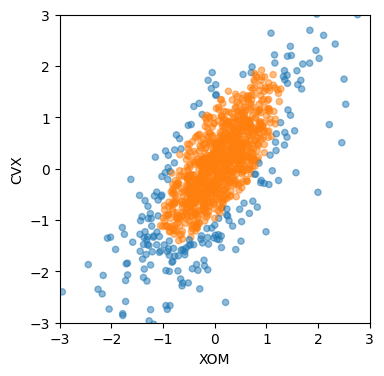

In [31]:
fig, ax = plt.subplots(figsize=(4, 4))
colors = [f'C{c}' for c in mclust.predict(df)]
df.plot.scatter(x='XOM', y='CVX', c=colors, alpha=0.5, ax=ax)
ax.set_xlim(-3, 3)
ax.set_ylim(-3, 3)

In [32]:
print('Mean')
print(mclust.means_)
print('Covariances')
print(mclust.covariances_)

Mean
[[-0.05050178 -0.21237957]
 [ 0.07225117  0.10452744]]
Covariances
[[[0.97385279 0.98028909]
  [0.98028909 1.67646834]]

 [[0.26868436 0.27606914]
  [0.27606914 0.51762673]]]


In [33]:
df["cluster"] = mclust.predict(df)
df

,XOM,CVX,cluster
Unnamed: 0,,,
2011-01-03,0.736805,0.240681,1
2011-01-04,0.168668,-0.584516,1
2011-01-05,0.026631,0.446985,1
2011-01-06,0.248558,-0.919751,0
2011-01-07,0.337329,0.180511,1
...,...,...,...
2015-06-25,-0.919998,-1.110001,1
2015-06-26,0.029999,0.360000,1
2015-06-29,-0.230003,-0.809998,1


In [34]:
df.groupby("cluster").mean().loc[0]

XOM   -0.205528
CVX   -0.532388
Name: 0, dtype: float64

In [35]:
df.groupby("cluster").cov()

XOM       CVX
cluster                        
0       XOM  1.620901  1.578261
        CVX  1.578261  2.635233
1       XOM  0.243600  0.249072
        CVX  0.249072  0.468088

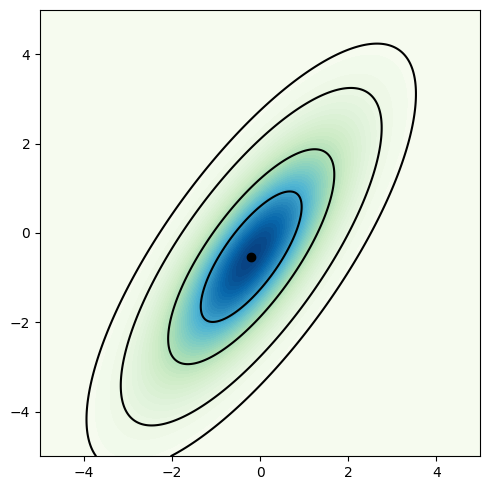

In [36]:
mean = df.groupby("cluster").mean().loc[0].values
cov = df.groupby("cluster").cov().loc[0].values
probability = [.5, .75, .95, .99]
def probLevel(p):
    D = 1
    return (1 - p) / (2 * np.pi * D)
levels = [probLevel(p) for p in probability]

fig, ax = plt.subplots(figsize=(5, 5))

x, y = np.mgrid[-5:5:.01, -5:5:.01]
pos = np.empty(x.shape + (2,))
pos[:, :, 0] = x; pos[:, :, 1] = y
rv = multivariate_normal(mean, cov)


CS = ax.contourf(x, y, rv.pdf(pos), cmap=GnBu, levels=50)
ax.contour(CS, levels=levels, colors=['black'])
ax.plot(*mean, color='black', marker='o')


plt.tight_layout()
plt.show()

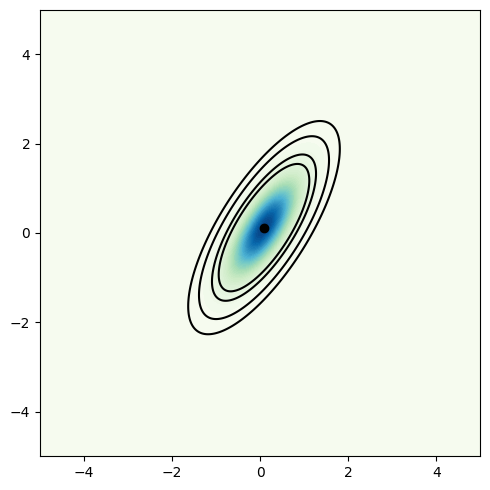

In [37]:
mean = df.groupby("cluster").mean().loc[1].values
cov = df.groupby("cluster").cov().loc[1].values
probability = [.5, .75, .95, .99]
def probLevel(p):
    D = 1
    return (1 - p) / (2 * np.pi * D)
levels = [probLevel(p) for p in probability]

fig, ax = plt.subplots(figsize=(5, 5))

x, y = np.mgrid[-5:5:.01, -5:5:.01]
pos = np.empty(x.shape + (2,))
pos[:, :, 0] = x; pos[:, :, 1] = y
rv = multivariate_normal(mean, cov)


CS = ax.contourf(x, y, rv.pdf(pos), cmap=GnBu, levels=50)
ax.contour(CS, levels=levels, colors=['black'])
ax.plot(*mean, color='black', marker='o')


plt.tight_layout()
plt.show()

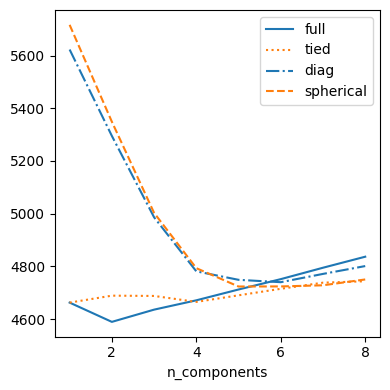

In [38]:
df = df[["XOM","CVX"]]
results = []
covariance_types = ['full', 'tied', 'diag', 'spherical']
for n_components in range(1, 9):
    for covariance_type in covariance_types:
        mclust = GaussianMixture(n_components = n_components, warm_start=True,
                                 covariance_type = covariance_type)
        mclust.fit(df)
        results.append({
            'bic': mclust.bic(df),
            'n_components': n_components,
            'covariance_type': covariance_type,
        })
        
results = pd.DataFrame(results)

colors = ['C0', 'C1', 'C2', 'C3']
styles = ['C0-','C1:','C0-.', 'C1--']

fig, ax = plt.subplots(figsize=(4, 4))
for i, covariance_type in enumerate(covariance_types):
    subset = results.loc[results.covariance_type == covariance_type, :]
    subset.plot(x='n_components', y='bic', ax=ax, label=covariance_type, 
                kind='line', style=styles[i]) # , color=colors[i])

plt.tight_layout()
plt.show()

In [39]:
loan_data = pd.read_csv("data/loan_data.csv")
loan_data

,Unnamed: 0,status,loan_amnt,term,annual_inc,dti,payment_inc_ratio,revol_bal,revol_util,purpose,...,delinq_2yrs_zero,pub_rec_zero,open_acc,grade,outcome,emp_length,purpose_,home_,emp_len_,borrower_score
0,1,Charged Off,2500,60 months,30000,1.00,2.39320,1687,9.4,car,...,1,1,3,4.8,default,1,major_purchase,RENT,> 1 Year,0.65
1,2,Charged Off,5600,60 months,40000,5.55,4.57170,5210,32.6,small_business,...,1,1,11,1.4,default,5,small_business,OWN,> 1 Year,0.80
2,3,Charged Off,5375,60 months,15000,18.08,9.71600,9279,36.5,other,...,1,1,2,6.0,default,1,other,RENT,> 1 Year,0.60
3,4,Charged Off,9000,36 months,30000,10.08,12.21520,10452,91.7,debt_consolidation,...,1,1,4,4.2,default,1,debt_consolidation,RENT,> 1 Year,0.50
4,5,Charged Off,10000,36 months,100000,7.06,3.90888,11997,55.5,other,...,1,1,14,5.4,default,4,other,RENT,> 1 Year,0.55
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45337,45338,Fully Paid,8000,36 months,72000,18.97,4.57850,9725,58.2,credit_card,...,1,0,9,4.2,paid off,8,credit_card,RENT,> 1 Year,0.35
45338,45339,Fully Paid,2000,36 months,25200,13.24,3.20333,4925,40.7,wedding,...,0,1,13,4.2,paid off,3,other,MORTGAGE,> 1 Year,0.50
45339,45340,Fully Paid,4375,36 months,20000,7.95,9.98460,6574,73.0,debt_consolidation,...,1,1,8,2.4,paid off,1,debt_consolidation,MORTGAGE,> 1 Year,0.55
45340,45341,Fully Paid,8000,36 months,48000,26.91,6.45250,10303,32.4,debt_consolidation,...,1,1,10,5.2,paid off,1,debt_consolidation,MORTGAGE,> 1 Year,0.65


In [40]:

loan_data['outcome'] = pd.Categorical(loan_data['outcome'], 
                                      categories=['paid off', 'default'], 
                                      ordered=True)
defaults = loan_data.loc[loan_data['outcome'] == 'default',]

columns = ['loan_amnt', 'annual_inc', 'revol_bal', 'open_acc', 
           'dti', 'revol_util']

df = defaults[columns]
kmeans = KMeans(n_clusters=4, random_state=1, n_init='auto').fit(df)
counts = Counter(kmeans.labels_)

centers = pd.DataFrame(kmeans.cluster_centers_, columns=columns)
centers['size'] = [counts[i] for i in range(4)]
print(centers)

      loan_amnt     annual_inc     revol_bal   open_acc        dti  \
0  17809.760881   78669.452556  18933.405997  11.594003  17.016428   
1  21444.318867  148736.057263  33152.689572  12.376733  13.831145   
2  24290.909091  409746.465909  84710.988636  13.431818   8.148636   
3  10274.160906   41241.205530   9950.095008   9.480338  17.718588   

   revol_util   size  
0   62.183810   7906  
1   63.151084   1654  
2   60.015647     88  
3   57.903425  13023  


In [41]:
loan_data

,Unnamed: 0,status,loan_amnt,term,annual_inc,dti,payment_inc_ratio,revol_bal,revol_util,purpose,...,delinq_2yrs_zero,pub_rec_zero,open_acc,grade,outcome,emp_length,purpose_,home_,emp_len_,borrower_score
0,1,Charged Off,2500,60 months,30000,1.00,2.39320,1687,9.4,car,...,1,1,3,4.8,default,1,major_purchase,RENT,> 1 Year,0.65
1,2,Charged Off,5600,60 months,40000,5.55,4.57170,5210,32.6,small_business,...,1,1,11,1.4,default,5,small_business,OWN,> 1 Year,0.80
2,3,Charged Off,5375,60 months,15000,18.08,9.71600,9279,36.5,other,...,1,1,2,6.0,default,1,other,RENT,> 1 Year,0.60
3,4,Charged Off,9000,36 months,30000,10.08,12.21520,10452,91.7,debt_consolidation,...,1,1,4,4.2,default,1,debt_consolidation,RENT,> 1 Year,0.50
4,5,Charged Off,10000,36 months,100000,7.06,3.90888,11997,55.5,other,...,1,1,14,5.4,default,4,other,RENT,> 1 Year,0.55
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45337,45338,Fully Paid,8000,36 months,72000,18.97,4.57850,9725,58.2,credit_card,...,1,0,9,4.2,paid off,8,credit_card,RENT,> 1 Year,0.35
45338,45339,Fully Paid,2000,36 months,25200,13.24,3.20333,4925,40.7,wedding,...,0,1,13,4.2,paid off,3,other,MORTGAGE,> 1 Year,0.50
45339,45340,Fully Paid,4375,36 months,20000,7.95,9.98460,6574,73.0,debt_consolidation,...,1,1,8,2.4,paid off,1,debt_consolidation,MORTGAGE,> 1 Year,0.55
45340,45341,Fully Paid,8000,36 months,48000,26.91,6.45250,10303,32.4,debt_consolidation,...,1,1,10,5.2,paid off,1,debt_consolidation,MORTGAGE,> 1 Year,0.65


In [42]:
defaults

,Unnamed: 0,status,loan_amnt,term,annual_inc,dti,payment_inc_ratio,revol_bal,revol_util,purpose,...,delinq_2yrs_zero,pub_rec_zero,open_acc,grade,outcome,emp_length,purpose_,home_,emp_len_,borrower_score
0,1,Charged Off,2500,60 months,30000,1.00,2.39320,1687,9.4,car,...,1,1,3,4.8,default,1,major_purchase,RENT,> 1 Year,0.65
1,2,Charged Off,5600,60 months,40000,5.55,4.57170,5210,32.6,small_business,...,1,1,11,1.4,default,5,small_business,OWN,> 1 Year,0.80
2,3,Charged Off,5375,60 months,15000,18.08,9.71600,9279,36.5,other,...,1,1,2,6.0,default,1,other,RENT,> 1 Year,0.60
3,4,Charged Off,9000,36 months,30000,10.08,12.21520,10452,91.7,debt_consolidation,...,1,1,4,4.2,default,1,debt_consolidation,RENT,> 1 Year,0.50
4,5,Charged Off,10000,36 months,100000,7.06,3.90888,11997,55.5,other,...,1,1,14,5.4,default,4,other,RENT,> 1 Year,0.55
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22666,22667,Charged Off,15250,60 months,45000,17.84,11.55790,960,32.0,debt_consolidation,...,0,1,7,3.0,default,3,debt_consolidation,RENT,> 1 Year,0.50
22667,22668,Charged Off,10000,36 months,50000,21.20,7.97040,2204,18.7,debt_consolidation,...,1,1,9,5.6,default,5,debt_consolidation,MORTGAGE,> 1 Year,0.60
22668,22669,Charged Off,25925,36 months,83000,9.60,12.03640,33314,53.9,credit_card,...,1,1,8,5.2,default,9,credit_card,MORTGAGE,> 1 Year,0.50
22669,22670,Charged Off,13375,36 months,43052,18.62,13.28970,9925,82.0,other,...,1,1,5,3.2,default,3,other,RENT,> 1 Year,0.50


/var/folders/nw/yjct11rn2lq_yqyn7t95tx0w0000gn/T/ipykernel_36186/1074019550.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  defaults["cluster"] = kmeans.labels_


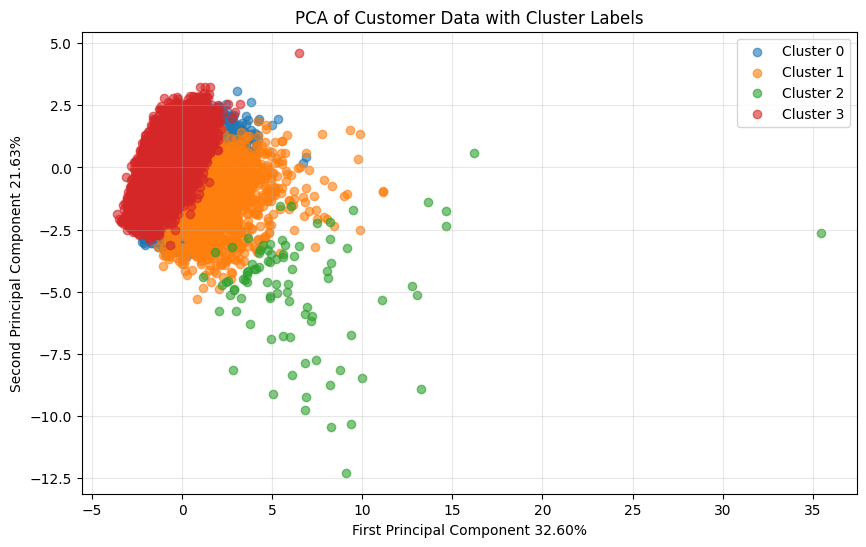

In [43]:
from sklearn.preprocessing import StandardScaler

defaults["cluster"] = kmeans.labels_
# First standardize the features since PCA is sensitive to scale
scaler = StandardScaler()
# Exclude cluster column and any non-numeric columns
features = ['loan_amnt', 'annual_inc', 'revol_bal', 'open_acc', 'dti', 'revol_util']
X_scaled = scaler.fit_transform(defaults[features])

# Apply PCA
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# Create visualization
plt.figure(figsize=(10, 6))

# Scatter plot with first two principal components
for cluster_id in range(len(colors)):
    mask = defaults['cluster'] == cluster_id
    plt.scatter(
        X_pca[mask, 0], 
        X_pca[mask, 1],
        c=colors[cluster_id],
        label=f'Cluster {cluster_id}',
        alpha=0.6
    )

# Add labels and title
plt.xlabel(f'First Principal Component {pca.explained_variance_ratio_[0]*100:.2f}%')
plt.ylabel(f'Second Principal Component {pca.explained_variance_ratio_[1]*100:.2f}%')
plt.title('PCA of Customer Data with Cluster Labels')
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

In [66]:

loan_data['outcome'] = pd.Categorical(loan_data['outcome'], 
                                      categories=['paid off', 'default'], 
                                      ordered=True)
paid_offs = loan_data.loc[loan_data['outcome'] == 'paid off',]

columns = ['loan_amnt', 'annual_inc', 'revol_bal', 'open_acc', 
           'dti', 'revol_util']

df = defaults[columns]
kmeans = KMeans(n_clusters=4, random_state=1, n_init='auto').fit(df)
counts = Counter(kmeans.labels_)

centers = pd.DataFrame(kmeans.cluster_centers_, columns=columns)
centers['size'] = [counts[i] for i in range(4)]
print(centers)

      loan_amnt     annual_inc     revol_bal   open_acc        dti  \
0  17809.760881   78669.452556  18933.405997  11.594003  17.016428   
1  21444.318867  148736.057263  33152.689572  12.376733  13.831145   
2  24290.909091  409746.465909  84710.988636  13.431818   8.148636   
3  10274.160906   41241.205530   9950.095008   9.480338  17.718588   

   revol_util   size  
0   62.183810   7906  
1   63.151084   1654  
2   60.015647     88  
3   57.903425  13023  


/var/folders/nw/yjct11rn2lq_yqyn7t95tx0w0000gn/T/ipykernel_36186/3929143631.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  paid_offs["cluster"] = kmeans.labels_


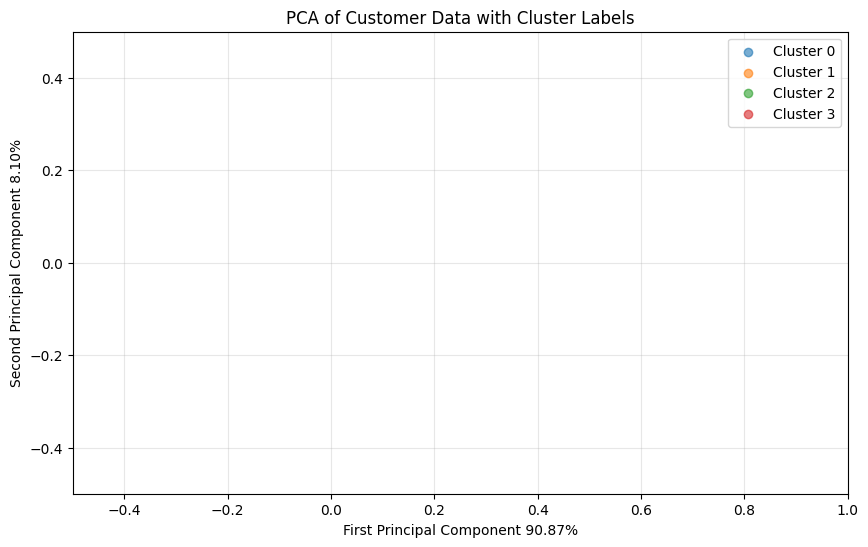

In [67]:
paid_offs["cluster"] = kmeans.labels_
# First standardize the features since PCA is sensitive to scale
scaler = StandardScaler()
# Exclude cluster column and any non-numeric columns
features = ['loan_amnt', 'annual_inc', 'revol_bal', 'open_acc', 'dti', 'revol_util']
X_scaled = scaler.fit_transform(paid_offs[features])

# Apply PCA
pca = PCA()
X_pca = pca.fit_transform(paid_offs[features])

# Create visualization
plt.figure(figsize=(10, 6))

# Scatter plot with first two principal components
for cluster_id in range(len(colors)):
    mask = paid_offs['cluster'] == cluster_id
    plt.scatter(
        X_pca[mask, 0], 
        X_pca[mask, 1],
        c=colors[cluster_id],
        label=f'Cluster {cluster_id}',
        alpha=0.6
    )

# Add labels and title
plt.xlabel(f'First Principal Component {pca.explained_variance_ratio_[0]*100:.2f}%')
plt.ylabel(f'Second Principal Component {pca.explained_variance_ratio_[1]*100:.2f}%')
plt.title('PCA of Customer Data with Cluster Labels')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xlim(-0.5,1)
plt.ylim(-0.5,0.5)

plt.show()

In [46]:
X_scaled

array([[ 0.26486334, -0.46386689,  0.04941899, -0.29559199,  0.5662176 ,
         0.01875988],
       [ 0.31620473, -0.48452473,  0.036874  , -1.15134041, -0.05619201,
         1.92440563],
       [ 0.18785124, -0.52660771, -0.6178301 , -0.7234662 ,  0.94913482,
        -0.99216194],
       ...,
       [-1.04755116, -0.77963675, -0.38941465, -0.50952909, -0.96951047,
         0.80115916],
       [-0.58226974, -0.36647993, -0.20949045, -0.08165488,  1.5958996 ,
        -0.77138591],
       [ 2.88327465,  0.4008113 ,  0.09800673,  0.56015644, -0.9871003 ,
         1.52158621]], shape=(22671, 6))

In [47]:
X_pca

array([[-3.12005313e+04,  3.57538541e+03,  2.70457707e+03,
        -3.29312021e-01,  2.64283025e+00, -2.50112854e+00],
       [-3.26022876e+04,  3.46234925e+03,  3.16272904e+03,
         4.85115209e+01, -5.79851742e+00, -2.50544910e+00],
       [-3.64537855e+04, -9.88690202e+03,  3.62710442e+03,
        -2.24091838e+01,  6.90647319e+00, -6.11797292e+00],
       ...,
       [-5.35118084e+04, -4.87347471e+03, -6.01627044e+03,
         2.27937576e+01, -8.52604706e+00,  2.37484642e+00],
       [-2.52155733e+04, -2.90481078e+03, -3.46805379e+03,
        -1.75763906e+01,  1.22696826e+01, -4.45629699e+00],
       [ 2.79346588e+04,  2.23819733e+03,  2.14762438e+04,
         3.48932523e+01, -9.66113966e+00,  4.71532027e+00]],
      shape=(22671, 6))

In [48]:
loan_data['outcome'] = pd.Categorical(loan_data['outcome'], 
                                      categories=['paid off', 'default'], 
                                      ordered=True)

columns = ['loan_amnt', 'annual_inc', 'revol_bal', 'open_acc', 
           'dti', 'revol_util']

df1 = loan_data[columns]
kmeans = KMeans(n_clusters=2, random_state=1, n_init='auto').fit(df1)
counts = Counter(kmeans.labels_)

centers = pd.DataFrame(kmeans.cluster_centers_, columns=columns)
centers['size'] = [counts[i] for i in range(2)]
print(centers)

      loan_amnt    annual_inc     revol_bal  open_acc        dti  revol_util  \
0  13154.777685  6.805569e+04  14857.524757  10.41296  16.134082   56.051472   
1  14825.000000  7.141778e+06  11351.000000  17.00000   0.250000   70.900000   

    size  
0  45341  
1      1  


/var/folders/nw/yjct11rn2lq_yqyn7t95tx0w0000gn/T/ipykernel_36186/2685979431.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1["cluster"] = kmeans.labels_


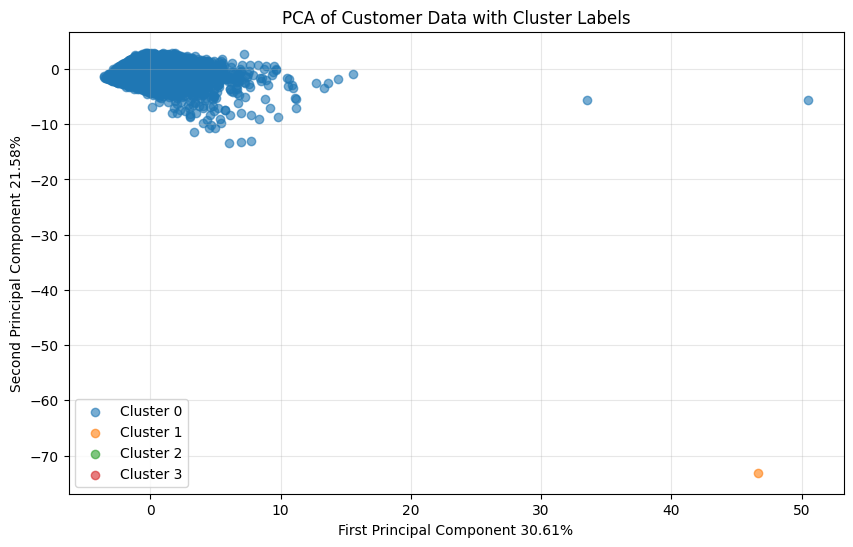

In [49]:

df1["cluster"] = kmeans.labels_
# First standardize the features since PCA is sensitive to scale
scaler = StandardScaler()
# Exclude cluster column and any non-numeric columns
features = ['loan_amnt', 'annual_inc', 'revol_bal', 'open_acc', 'dti', 'revol_util']
X_scaled = scaler.fit_transform(df1[features])

# Apply PCA
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# Create visualization
plt.figure(figsize=(10, 6))

# Scatter plot with first two principal components
for cluster_id in range(len(colors)):
    mask = df1['cluster'] == cluster_id
    plt.scatter(
        X_pca[mask, 0], 
        X_pca[mask, 1],
        c=colors[cluster_id],
        label=f'Cluster {cluster_id}',
        alpha=0.6
    )

# Add labels and title
plt.xlabel(f'First Principal Component {pca.explained_variance_ratio_[0]*100:.2f}%')
plt.ylabel(f'Second Principal Component {pca.explained_variance_ratio_[1]*100:.2f}%')
plt.title('PCA of Customer Data with Cluster Labels')
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

In [50]:
df1.cluster.value_counts()

cluster
0    45341
1        1
Name: count, dtype: int64

In [51]:
loan_data['outcome'] = pd.Categorical(loan_data['outcome'], 
                                      categories=['paid off', 'default'], 
                                      ordered=True)

columns = ['loan_amnt', 'annual_inc', 'revol_bal', 'open_acc', 
           'dti', 'revol_util']

df1 = loan_data[columns]

scaler = StandardScaler()
df_scaled = scaler.fit_transform(df1)
kmeans = KMeans(n_clusters=2, random_state=1, n_init='auto').fit(df_scaled)
counts = Counter(kmeans.labels_)

centers = pd.DataFrame(kmeans.cluster_centers_, columns=columns)
centers['size'] = [counts[i] for i in range(2)]
print(centers)

   loan_amnt  annual_inc  revol_bal  open_acc       dti  revol_util   size
0  -0.488708   -0.208758  -0.318946 -0.444883 -0.353451   -0.195541  26659
1   0.702251    0.299975   0.458312  0.639277  0.507894    0.280984  18683


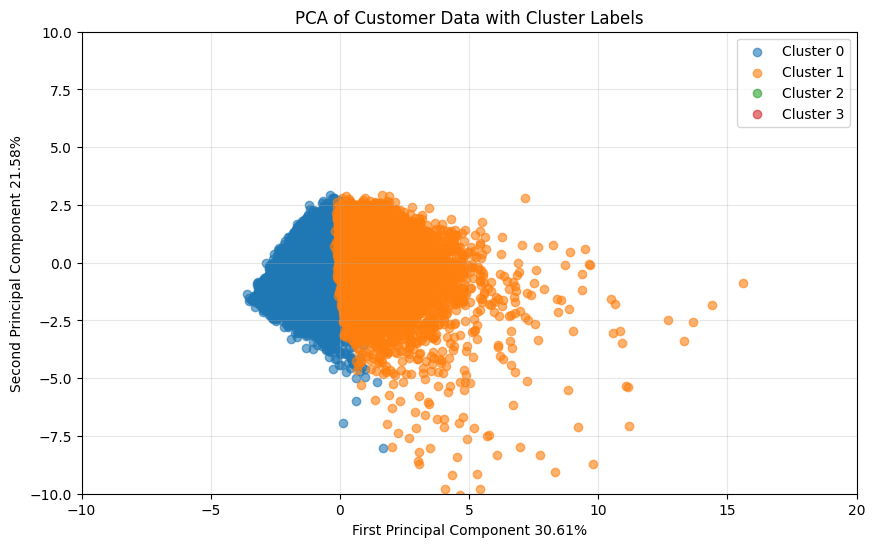

In [52]:
features = ['loan_amnt', 'annual_inc', 'revol_bal', 'open_acc', 'dti', 'revol_util']

df_scaled = pd.DataFrame(df_scaled, columns=features)
df_scaled["cluster"] = kmeans.labels_
# First standardize the features since PCA is sensitive to scale
# Exclude cluster column and any non-numeric columns

# Apply PCA
pca = PCA()
X_pca = pca.fit_transform(df_scaled[features])

# Create visualization
plt.figure(figsize=(10, 6))

# Scatter plot with first two principal components
for cluster_id in range(len(colors)):
    mask = df_scaled['cluster'] == cluster_id
    plt.scatter(
        X_pca[mask, 0], 
        X_pca[mask, 1],
        c=colors[cluster_id],
        label=f'Cluster {cluster_id}',
        alpha=0.6
    )

# Add labels and title
plt.xlabel(f'First Principal Component {pca.explained_variance_ratio_[0]*100:.2f}%')
plt.ylabel(f'Second Principal Component {pca.explained_variance_ratio_[1]*100:.2f}%')
plt.title('PCA of Customer Data with Cluster Labels')
plt.xlim(-10,20)
plt.ylim(-10,10)
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

In [53]:
# scaler = StandardScaler()
# df0 = scaler.fit_transform(df * 1.0)
# kmeans = KMeans(n_clusters=4, random_state=1).fit(df0)
# counts = Counter(kmeans.labels_)
# centers = pd.DataFrame(scaler.inverse_transform(kmeans.cluster_centers_),
#  columns=columns)
# centers['size'] = [counts[i] for i in range(4)]
# centers

In [54]:
df_scaled

,loan_amnt,annual_inc,revol_bal,open_acc,dti,revol_util,cluster
0,-1.317288,-0.679459,-0.655823,-1.578410,-1.992645,-1.834519,0
1,-0.934026,-0.501645,-0.480395,0.124963,-1.393550,-0.922210,0
2,-0.961843,-0.946181,-0.277779,-1.791332,0.256263,-0.768848,0
3,-0.513673,-0.679459,-0.219369,-1.365488,-0.797089,1.401817,0
4,-0.390040,0.565242,-0.142436,0.763727,-1.194730,-0.021699,0
...,...,...,...,...,...,...,...
45337,-0.637306,0.067362,-0.255570,-0.300881,0.373449,0.084475,0
45338,-1.379105,-0.764810,-0.494587,0.550806,-0.381015,-0.603689,0
45339,-1.085476,-0.857274,-0.412475,-0.513802,-1.077544,0.666465,0
45340,-0.637306,-0.359393,-0.226789,-0.087959,1.418901,-0.930075,0


In [55]:
from sklearn.metrics import roc_auc_score, accuracy_score

knn_predicts = [1 if i == "default" else 0 for i in df_scaled.cluster.values]
outcomes = [1 if i == "default" else 0 for i in loan_data.outcome.values]
print(roc_auc_score(outcomes, knn_predicts))
print(accuracy_score(outcomes, knn_predicts))

0.5
0.5


In [56]:
scaler = StandardScaler()
df0 = scaler.fit_transform(df1 * 1.0)
kmeans = KMeans(n_clusters=4, random_state=1).fit(df0)
counts = Counter(kmeans.labels_)
centers = pd.DataFrame(scaler.inverse_transform(kmeans.cluster_centers_),
 columns=columns)
centers['size'] = [counts[i] for i in range(4)]
centers

,loan_amnt,annual_inc,revol_bal,open_acc,dti,revol_util,size
0,10110.527396,55690.653054,11775.687872,7.512484,15.229194,75.438838,14639
1,12353.028378,58564.169081,15832.490470,14.435578,23.321499,55.508336,11786
2,25567.314166,118305.142607,32946.913951,12.378266,15.874029,63.307257,7424
3,9830.266707,61680.217630,6086.953272,8.701096,10.068676,27.259374,11493


In [57]:

df1 = pd.DataFrame({'A': [1, 2, None], 'B': [4, None, 6]})
df1 = df1.fillna(0)
print(df1)

     A    B
0  1.0  4.0
1  2.0  0.0
2  0.0  6.0


Text(0.5, 0, 'Component')

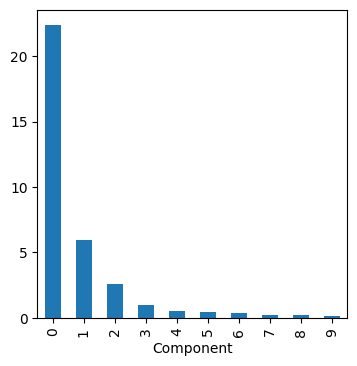

In [58]:
syms = ['GOOGL', 'AMZN', 'AAPL', 'MSFT', 'CSCO', 'INTC', 'CVX', 'XOM',
 'SLB', 'COP', 'JPM', 'WFC', 'USB', 'AXP', 'WMT', 'TGT', 'HD', 'COST']
top_sp1 = sp500_px.loc[sp500_px.index >= '2005-01-01', syms]
sp_pca1 = PCA()
sp_pca1.fit(top_sp1)
explained_variance = pd.DataFrame(sp_pca1.explained_variance_)
ax = explained_variance.head(10).plot.bar(legend=False, figsize=(4, 4))
ax.set_xlabel('Component')

In [59]:
loadings = pd.DataFrame(sp_pca1.components_[0:2, :], columns=top_sp1.columns)
loadings.transpose()

,0,1
GOOGL,0.857310,-0.477873
AMZN,0.444728,0.874149
AAPL,0.071627,0.020802
MSFT,0.036002,0.006204
CSCO,0.029205,0.003045
INTC,0.026666,0.006069
CVX,0.089548,0.037420
XOM,0.080336,0.020511
SLB,0.110218,0.030356
COP,0.057739,0.024117


In [60]:
top_sp1

,GOOGL,AMZN,AAPL,MSFT,CSCO,INTC,CVX,XOM,SLB,COP,JPM,WFC,USB,AXP,WMT,TGT,HD,COST
Unnamed: 0,,,,,,,,,,,,,,,,,,
2005-01-03,2.657662,-0.430001,-0.099973,-0.047835,-0.089263,-0.423310,-1.103047,-0.728723,-1.110633,-0.696598,-0.248896,-0.120469,-0.110006,-0.513656,-0.320960,-0.724329,0.084594,-0.273346
2005-01-04,-3.453445,-0.529999,0.010060,-0.023919,-0.731955,-0.430737,-0.304046,-0.462308,-0.387634,-0.205508,-0.433680,0.003764,-0.110004,-0.625311,-0.441318,-0.757632,-0.530658,-0.924551
2005-01-05,0.030030,0.200000,0.002677,-0.047835,0.089264,-0.059412,0.148490,-0.266415,0.087109,0.208174,-0.083690,-0.018824,0.080668,-0.455095,-0.168503,-0.124885,-0.261482,0.032159
2005-01-06,-3.268272,-0.760002,-0.008059,-0.079726,0.160673,-0.089119,0.657588,0.642530,0.587981,0.325615,-0.045651,0.056471,-0.029335,-0.134286,0.120357,-1.423682,-0.484512,-0.771800
2005-01-07,1.606598,0.939999,0.285154,-0.119589,-0.178526,0.051985,-0.410107,-0.258578,-0.574915,-0.144125,-0.220642,-0.064000,-0.256675,-0.387940,-0.048141,0.349678,-0.161506,-0.104512
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2015-06-25,-2.349976,2.029999,-1.360001,-0.379997,-0.158775,-0.030000,-1.110001,-0.919998,-0.690003,-0.949997,-0.665647,-0.580002,-0.238625,-1.105863,-0.589996,0.080002,-1.000000,-1.000000
2015-06-26,-6.650024,-3.660004,-0.919998,-0.390004,-0.208393,-0.490000,0.360000,0.029999,0.279999,0.029998,0.009930,0.099999,-0.020001,-0.288920,0.160004,-0.409996,-0.169999,0.119996
2015-06-29,-5.500000,-5.120026,-0.930000,-0.670002,-0.446558,-0.310002,-0.809998,-0.230003,0.060006,-0.410000,-0.476886,-0.739998,-0.500000,-1.414705,-0.380005,-1.390007,-1.019997,-1.319993


Text(0.5, 0, 'Component')

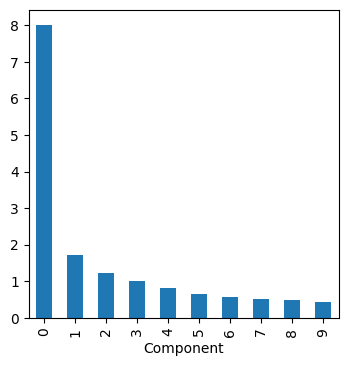

In [61]:
syms = ['GOOGL', 'AMZN', 'AAPL', 'MSFT', 'CSCO', 'INTC', 'CVX', 'XOM',
 'SLB', 'COP', 'JPM', 'WFC', 'USB', 'AXP', 'WMT', 'TGT', 'HD', 'COST']
top_sp1 = sp500_px.loc[sp500_px.index >= '2005-01-01', syms]

scaler = StandardScaler()

top_sp1_scaled = scaler.fit_transform(top_sp1)
sp_pca1 = PCA()
sp_pca1.fit(top_sp1_scaled)
explained_variance = pd.DataFrame(sp_pca1.explained_variance_)
ax = explained_variance.head(10).plot.bar(legend=False, figsize=(4, 4))
ax.set_xlabel('Component')

In [62]:
loadings = pd.DataFrame(sp_pca1.components_[0:2, :], columns=top_sp1.columns)
loadings.transpose()

,0,1
GOOGL,0.220376,-0.043901
AMZN,0.186224,-0.044513
AAPL,0.176025,-0.032181
MSFT,0.236321,-0.007349
CSCO,0.251647,-0.033820
INTC,0.236678,-0.037802
CVX,0.252598,0.418393
XOM,0.256584,0.379210
SLB,0.216233,0.413399
COP,0.232247,0.457359


Text(0.5, 0, 'Component')

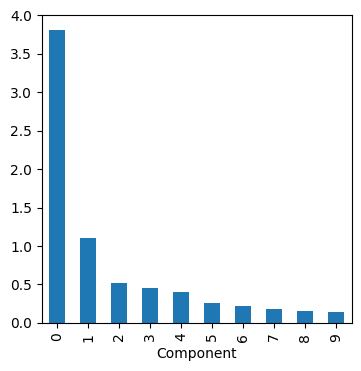

In [63]:
syms = ['AAPL', 'MSFT', 'CSCO', 'INTC', 'CVX', 'XOM',
 'SLB', 'COP', 'JPM', 'WFC', 'USB', 'AXP', 'WMT', 'TGT', 'HD', 'COST']
top_sp1 = sp500_px.loc[sp500_px.index >= '2005-01-01', syms]
sp_pca1 = PCA()
sp_pca1.fit(top_sp1)
explained_variance = pd.DataFrame(sp_pca1.explained_variance_)
ax = explained_variance.head(10).plot.bar(legend=False, figsize=(4, 4))
ax.set_xlabel('Component')

In [64]:
loadings = pd.DataFrame(sp_pca1.components_[0:2, :], columns=top_sp1.columns)
loadings.transpose()

,0,1
AAPL,0.162158,-0.137257
MSFT,0.096803,-0.066814
CSCO,0.086743,-0.060050
INTC,0.078133,-0.058747
CVX,0.409932,0.198798
XOM,0.362911,0.134578
SLB,0.520484,0.544855
COP,0.259769,0.166867
JPM,0.250115,-0.271628
WFC,0.183996,-0.218073


In [ ]:
columns = ['dti', 'payment_inc_ratio', 'home_', 'pub_rec_zero']
df = pd.get_dummies(defaults[columns])
scaler = StandardScaler()
df0 = scaler.fit_transform(df * 1.0)
kmeans = KMeans(n_clusters=4, random_state=1).fit(df0)
centers = pd.DataFrame(scaler.inverse_transform(kmeans.cluster_centers_), columns=df.columns)
centers

,dti,payment_inc_ratio,pub_rec_zero,home__MORTGAGE,home__OWN,home__RENT
0,21.431365,12.354001,0.943315,-1.443290e-15,-8.326673e-17,1.000000e+00
1,12.743276,5.918701,0.900372,1.665335e-16,-9.714451e-17,1.000000e+00
2,17.339786,8.353535,0.905716,1.000000e+00,-1.040834e-15,-5.107026e-15
3,17.197993,9.266666,0.917903,1.110223e-16,1.000000e+00,1.221245e-15


In [70]:
defaults[columns]

,dti,payment_inc_ratio,home_,pub_rec_zero
0,1.00,2.39320,RENT,1
1,5.55,4.57170,OWN,1
2,18.08,9.71600,RENT,1
3,10.08,12.21520,RENT,1
4,7.06,3.90888,RENT,1
...,...,...,...,...
22666,17.84,11.55790,RENT,1
22667,21.20,7.97040,MORTGAGE,1
22668,9.60,12.03640,MORTGAGE,1
22669,18.62,13.28970,RENT,1


In [71]:
df

,dti,payment_inc_ratio,pub_rec_zero,home__MORTGAGE,home__OWN,home__RENT
0,1.00,2.39320,1,False,False,True
1,5.55,4.57170,1,False,True,False
2,18.08,9.71600,1,False,False,True
3,10.08,12.21520,1,False,False,True
4,7.06,3.90888,1,False,False,True
...,...,...,...,...,...,...
22666,17.84,11.55790,1,False,False,True
22667,21.20,7.97040,1,True,False,False
22668,9.60,12.03640,1,True,False,False
22669,18.62,13.28970,1,False,False,True


In [75]:
df1 = pd.DataFrame(df0, columns=df.columns)
df1

,dti,payment_inc_ratio,pub_rec_zero,home__MORTGAGE,home__OWN,home__RENT
0,-2.108810,-1.458008,0.306167,-0.870938,-0.301403,1.029685
1,-1.514767,-0.959917,0.306167,-0.870938,3.317822,-0.971171
2,0.121137,0.216274,0.306167,-0.870938,-0.301403,1.029685
3,-0.923335,0.787690,0.306167,-0.870938,-0.301403,1.029685
4,-1.317623,-1.111464,0.306167,-0.870938,-0.301403,1.029685
...,...,...,...,...,...,...
22666,0.089803,0.637405,0.306167,-0.870938,-0.301403,1.029685
22667,0.528481,-0.182839,0.306167,1.148188,-0.301403,-0.971171
22668,-0.986003,0.746809,0.306167,1.148188,-0.301403,-0.971171
22669,0.191639,1.033363,0.306167,-0.870938,-0.301403,1.029685


In [ ]:
df1.home__OWN.value_counts()

dti        payment_inc_ratio  pub_rec_zero  home__MORTGAGE  home__OWN  home__RENT
-2.239369  -1.967148           0.306167      1.148188       -0.301403  -0.971171     1
 0.471035  -0.227369           0.306167     -0.870938       -0.301403   1.029685     1
 0.468424  -0.523714           0.306167      1.148188       -0.301403  -0.971171     1
           -0.678027          -3.266196     -0.870938        3.317822  -0.971171     1
           -0.721041           0.306167     -0.870938       -0.301403   1.029685     1
                                                                                    ..
-0.472906   0.910012           0.306167      1.148188       -0.301403  -0.971171     1
           -0.502725           0.306167      1.148188       -0.301403  -0.971171     1
           -0.734357           0.306167     -0.870938        3.317822  -0.971171     1
           -0.795914          -3.266196     -0.870938        3.317822  -0.971171     1
 2.496004  -1.467092           0.306167      1.1